<a href="https://colab.research.google.com/github/varchu04/smart-waste-detection/blob/main/notebooks/02_dataset_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 — Dataset Exploration

This notebook performs exploratory data analysis on the waste classification dataset.

## Objectives

- Understand the dataset structure
- Identify waste categories
- Analyze training and testing distributions
- Inspect image dimensions
- Check image integrity
- Visualize representative samples
- Identify preprocessing requirements

In [1]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
dataset_path = "/kaggle/input/waste-classification-data"

train_path = os.path.join(
    dataset_path, "DATASET", "TRAIN"
)

test_path = os.path.join(
    dataset_path, "DATASET", "TEST"
)

print("Training path:", train_path)
print("Testing path:", test_path)

Training path: /kaggle/input/waste-classification-data/DATASET/TRAIN
Testing path: /kaggle/input/waste-classification-data/DATASET/TEST


In [4]:
!pip install -q kagglehub

In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "techsash/waste-classification-data"
)

print("Dataset path:")
print(dataset_path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset path:
/kaggle/input/waste-classification-data


In [6]:
import os

path = dataset_path

train_path = os.path.join(
    path,
    "DATASET",
    "TRAIN"
)

test_path = os.path.join(
    path,
    "DATASET",
    "TEST"
)

print("Training path:", train_path)
print("Testing path:", test_path)

Training path: /kaggle/input/waste-classification-data/DATASET/TRAIN
Testing path: /kaggle/input/waste-classification-data/DATASET/TEST


In [7]:
print("Training exists:", os.path.exists(train_path))
print("Testing exists:", os.path.exists(test_path))

Training exists: True
Testing exists: True


In [8]:
print("Training classes:", os.listdir(train_path))
print("Testing classes:", os.listdir(test_path))

Training classes: ['R', 'O']
Testing classes: ['R', 'O']


In [9]:
def count_images(folder):
    counts = {}

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            image_files = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                )
            ]

            counts[class_name] = len(image_files)

    return counts


train_counts = count_images(train_path)
test_counts = count_images(test_path)

print("Training data:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\nTesting data:")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")

Training data:
R: 9999
O: 12565

Testing data:
R: 1112
O: 1401


In [10]:
total_train = sum(train_counts.values())
total_test = sum(test_counts.values())
total_images = total_train + total_test

print("Total training images:", total_train)
print("Total testing images:", total_test)
print("Total images:", total_images)

print("\nTraining distribution:")
for cls, count in train_counts.items():
    percentage = (count / total_train) * 100
    label = "Recyclable" if cls == "R" else "Organic"
    print(f"{label}: {percentage:.2f}%")

Total training images: 22564
Total testing images: 2513
Total images: 25077

Training distribution:
Recyclable: 44.31%
Organic: 55.69%


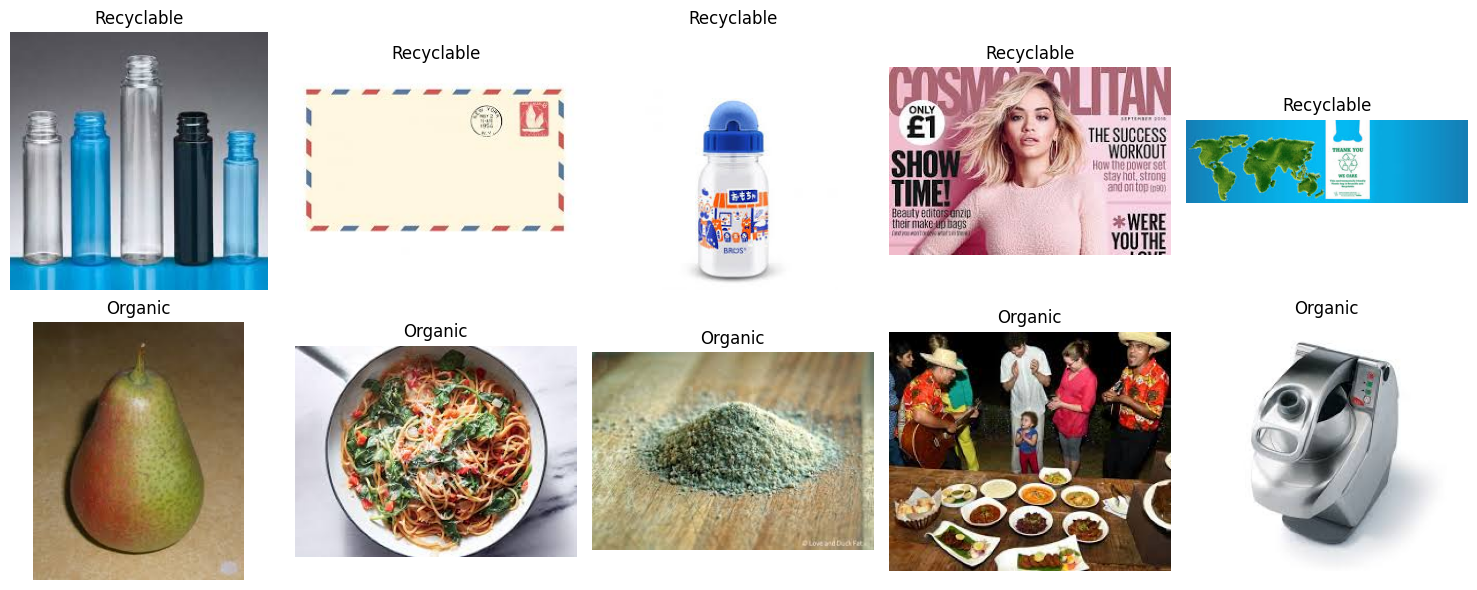

In [11]:
import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 6)
)

for row, class_name in enumerate(["R", "O"]):

    class_path = os.path.join(
        train_path,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    selected_images = random.sample(
        image_files,
        5
    )

    for col, image_file in enumerate(
        selected_images
    ):

        image_path = os.path.join(
            class_path,
            image_file
        )

        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        label = (
            "Recyclable"
            if class_name == "R"
            else "Organic"
        )

        axes[row, col].set_title(label)

plt.tight_layout()
plt.show()

## Visual Observations

The sample images show substantial variation in object type, background,
composition, and image dimensions.

The Recyclable class contains bottles, paper-based products, magazines,
maps, and other potentially recyclable materials. The Organic class
contains fruits, prepared food, and other organic materials.

Several images contain contextual backgrounds or complete scenes rather
than isolated waste objects. This may introduce dataset bias, where the
model could learn background or contextual features instead of the actual
waste category.

Therefore, model evaluation and error analysis will be important to
determine whether the learned features generalize to real-world waste
images.

In [13]:
def get_class_dimensions(folder):
    class_dimensions = {}

    for class_name in os.listdir(folder):

        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        dimensions = []

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ]

        for image_file in image_files:

            image_path = os.path.join(
                class_path,
                image_file
            )

            try:
                with Image.open(image_path) as img:
                    dimensions.append(img.size)

            except Exception:
                pass

        class_dimensions[class_name] = dimensions

    return class_dimensions


class_dimensions = get_class_dimensions(train_path)

for class_name, dimensions in class_dimensions.items():

    widths = [d[0] for d in dimensions]
    heights = [d[1] for d in dimensions]

    print(
        f"{class_name}: "
        f"{len(dimensions)} images | "
        f"Average width = {np.mean(widths):.1f} | "
        f"Average height = {np.mean(heights):.1f}"
    )

R: 9999 images | Average width = 242.3 | Average height = 211.7
O: 12565 images | Average width = 260.3 | Average height = 197.5


## Image Dimension Analysis

The dataset contains images with varying spatial dimensions and aspect
ratios.

The Recyclable class has an average image size of approximately
242.3 × 211.7 pixels, while the Organic class has an average size of
approximately 260.3 × 197.5 pixels.

This variation means that the model cannot directly receive the original
images as inputs. A standardized image size will be required during
preprocessing.

The difference in average dimensions between the classes is also worth
considering during model development because image composition or aspect
ratio could potentially become a shortcut feature. Later experiments will
therefore evaluate whether preprocessing and augmentation improve
generalization.

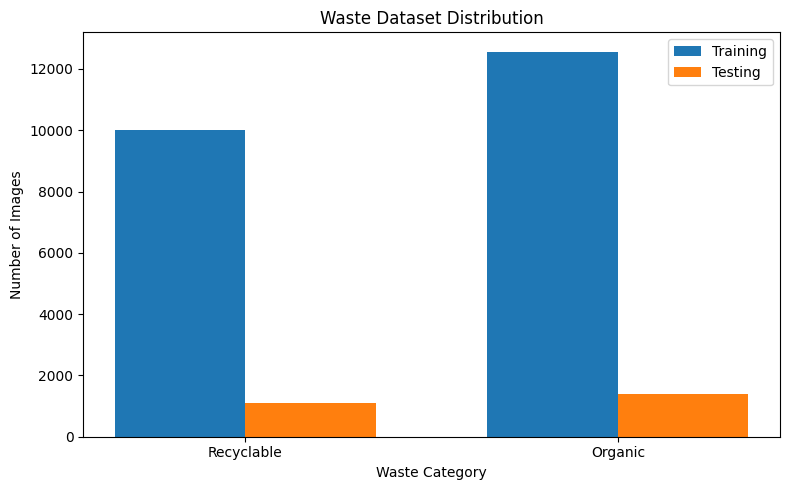

Chart saved successfully.


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Create output directory
os.makedirs(
    "/content/smart-waste-detection/results",
    exist_ok=True
)

# Class order
classes = ["R", "O"]

# Get counts
train_values = [train_counts[c] for c in classes]
test_values = [test_counts[c] for c in classes]

# Position and bar width
x = np.arange(len(classes))
width = 0.35

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training"
)

plt.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing"
)

plt.xticks(
    x,
    ["Recyclable", "Organic"]
)

plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.title("Waste Dataset Distribution")
plt.legend()

plt.tight_layout()

# Save chart
plt.savefig(
    "/content/smart-waste-detection/results/dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

In [16]:
x = np.arange(len(classes))
width = 0.35

In [17]:
import os

project_path = "/content/smart-waste-detection"

for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

smart-waste-detection/
    results/
        dataset_distribution.png


In [22]:
import os

print(os.listdir("/content"))

['.config', 'smart-waste-detection', 'sample_data']
